# Synthetic UNO Scene Generator

Inspired by [geaxgx/playing-card-detection](https://github.com/geaxgx/playing-card-detection).

Pipeline:
1. Load each card image + its two corner hulls from `annotations.csv` (HL = upper-left symbol, LR = lower-right symbol).
2. Random rotation + perspective warp on each card. Track where the hulls land.
3. Compose scenes on a random background:
   - **no-overlap**: 1–6 cards, rejected if their warped quads intersect.
   - **occlusion**: 2–3 cards stacked geaxgx-style. A card is kept only if at least one of its two corner hulls remains fully uncovered by the cards placed after it.
4. For each visible hull, write a YOLO bbox (the axis-aligned box around the warped hull).

In [8]:
from __future__ import annotations
import os, glob, random, math, json
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from shapely.geometry import Polygon
from shapely.affinity import affine_transform
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
CARDS_DIR = DATA_DIR / 'card_images'
BG_DIR = DATA_DIR / 'backgrounds'
OUT_DIR = ROOT / 'synthetic'
OUT_IMG = OUT_DIR / 'images'
OUT_LBL = OUT_DIR / 'labels'
for d in (OUT_IMG, OUT_LBL):
    d.mkdir(parents=True, exist_ok=True)

# Output scene canvas size — 3:2 aspect to match the real train images (4000x2662).
SCENE_W, SCENE_H = 1080, 720
# Card resize: pick a target longest-side so cards look natural on the canvas
CARD_LONG_SIDE = 220

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('Cards:', len(list(CARDS_DIR.glob('*.jpg'))))
print('Backgrounds:', len(list(BG_DIR.glob('*'))))

Cards: 54
Backgrounds: 2


In [9]:
# --- Load card sprites + corner hulls -------------------------------------
ann = pd.read_csv(DATA_DIR / 'annotations.csv')

CLASS_NAMES = sorted({p.stem for p in CARDS_DIR.glob('*.jpg')})
CLASS_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}
print(f'{len(CLASS_NAMES)} classes')

def load_card_bgra(path: Path) -> np.ndarray:
    """Load a JPG card and add a full-opaque alpha channel."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    alpha = np.full(img.shape[:2], 255, dtype=np.uint8)
    return np.dstack([img, alpha])

def hulls_for(card_filename: str):
    """Return list of (label, polygon_pts Nx2) for each corner of a card."""
    rows = ann[ann['image'] == card_filename]
    polys = []
    for _, r in rows.iterrows():
        x, y, w, h = int(r['posx']), int(r['posy']), int(r['width']), int(r['height'])
        # Rectangular hull around the corner symbol
        pts = np.array([[x, y], [x + w, y], [x + w, y + h], [x, y + h]], dtype=np.float32)
        polys.append((r['corner'], pts))
    return polys

CARDS = []  # list of dicts: {name, img_bgra, hulls:[Nx2], size:(w,h)}
for jpg in sorted(CARDS_DIR.glob('*.jpg')):
    img = load_card_bgra(jpg)
    h, w = img.shape[:2]
    polys = hulls_for(jpg.name)
    if not polys:
        # No annotation -> fallback: skip warning, still include card with empty hulls
        print(f'warn: no hulls for {jpg.name}')
    CARDS.append({'name': jpg.stem, 'file': jpg.name, 'img': img,
                  'hulls': polys, 'size': (w, h)})
print(f'Loaded {len(CARDS)} cards. Example hulls for {CARDS[0]["name"]}:',
      [(c, p.tolist()) for c, p in CARDS[0]['hulls']])


54 classes
Loaded 54 cards. Example hulls for b_0: [('HL', [[35.0, 29.0], [84.0, 29.0], [84.0, 90.0], [35.0, 90.0]]), ('LR', [[270.0, 438.0], [319.0, 438.0], [319.0, 499.0], [270.0, 499.0]])]


In [10]:
# --- Card transform: scale, rotate, perspective ---------------------------

def transform_points(M: np.ndarray, pts: np.ndarray) -> np.ndarray:
    """Apply 3x3 homography (or 2x3 affine) to Nx2 points."""
    pts = np.asarray(pts, dtype=np.float32)
    if M.shape == (2, 3):
        ones = np.ones((pts.shape[0], 1), dtype=np.float32)
        return (np.hstack([pts, ones]) @ M.T)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homog = np.hstack([pts, ones]) @ M.T
    return homog[:, :2] / homog[:, 2:3]


def warp_card(card: dict,
              scale: float = 1.0,
              angle: float | None = None,
              perspective: float = 0.10):
    """
    Returns:
        warped_bgra: HxWx4 image of the warped card on a transparent canvas
        warped_hulls: list of (label, Nx2 polygon in canvas coords)
        card_quad: 4x2 polygon of the warped card outline (canvas coords)
    """
    src = card['img']
    h, w = src.shape[:2]

    # 1. Resize to target long-side
    long_side = max(h, w)
    s = (CARD_LONG_SIDE / long_side) * scale
    new_w, new_h = int(w * s), int(h * s)
    resized = cv2.resize(src, (new_w, new_h), interpolation=cv2.INTER_AREA)
    scale_M = np.array([[s, 0, 0], [0, s, 0]], dtype=np.float32)
    hulls_s = [(lbl, transform_points(scale_M, pts)) for lbl, pts in card['hulls']]

    # 2. Rotation
    if angle is None:
        angle = random.uniform(-180, 180)
    cx, cy = new_w / 2, new_h / 2
    R = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    # Compute bounding canvas after rotation
    cos, sin = abs(R[0, 0]), abs(R[0, 1])
    rot_w = int(new_h * sin + new_w * cos)
    rot_h = int(new_h * cos + new_w * sin)
    R[0, 2] += rot_w / 2 - cx
    R[1, 2] += rot_h / 2 - cy
    rotated = cv2.warpAffine(resized, R, (rot_w, rot_h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0))
    hulls_r = [(lbl, transform_points(R, pts)) for lbl, pts in hulls_s]
    card_corners = np.array([[0, 0], [new_w, 0], [new_w, new_h], [0, new_h]], dtype=np.float32)
    quad = transform_points(R, card_corners)

    # 3. Mild perspective warp (random push of each corner)
    H, W = rotated.shape[:2]
    src_pts = np.array([[0, 0], [W, 0], [W, H], [0, H]], dtype=np.float32)
    jitter = perspective * min(W, H)
    dst_pts = src_pts + np.random.uniform(-jitter, jitter, src_pts.shape).astype(np.float32)
    # Re-frame so dst is in positive coords
    minxy = dst_pts.min(axis=0)
    dst_pts -= minxy
    out_w = int(math.ceil(dst_pts[:, 0].max())) + 1
    out_h = int(math.ceil(dst_pts[:, 1].max())) + 1
    Hp = cv2.getPerspectiveTransform(src_pts, dst_pts)
    persp = cv2.warpPerspective(rotated, Hp, (out_w, out_h),
                                flags=cv2.INTER_LINEAR,
                                borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0))
    hulls_p = [(lbl, transform_points(Hp, pts)) for lbl, pts in hulls_r]
    quad_p = transform_points(Hp, quad)
    return persp, hulls_p, quad_p


def paste_bgra(canvas: np.ndarray, sprite: np.ndarray, x: int, y: int) -> np.ndarray:
    """Alpha-blend `sprite` onto `canvas` at top-left (x, y). Returns canvas mutated."""
    H, W = canvas.shape[:2]
    sh, sw = sprite.shape[:2]
    x0, y0 = max(x, 0), max(y, 0)
    x1, y1 = min(x + sw, W), min(y + sh, H)
    if x1 <= x0 or y1 <= y0:
        return canvas
    sx0, sy0 = x0 - x, y0 - y
    sx1, sy1 = sx0 + (x1 - x0), sy0 + (y1 - y0)
    region = canvas[y0:y1, x0:x1]
    patch = sprite[sy0:sy1, sx0:sx1]
    alpha = patch[..., 3:4].astype(np.float32) / 255.0
    region[..., :3] = (patch[..., :3].astype(np.float32) * alpha
                      + region[..., :3].astype(np.float32) * (1 - alpha)).astype(np.uint8)
    if canvas.shape[2] == 4:
        region[..., 3] = np.maximum(region[..., 3], patch[..., 3])
    canvas[y0:y1, x0:x1] = region
    return canvas


In [11]:
# --- Background loader & scene composers ----------------------------------

BG_FILES = sorted([p for p in BG_DIR.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])

def random_background() -> np.ndarray:
    """Random crop of a random background image, resized to (SCENE_H, SCENE_W)."""
    if not BG_FILES:
        return np.random.randint(0, 255, (SCENE_H, SCENE_W, 3), dtype=np.uint8)
    bg = cv2.imread(str(random.choice(BG_FILES)))
    h, w = bg.shape[:2]
    # Random crop covering the aspect, then resize to canvas
    target_ar = SCENE_W / SCENE_H
    src_ar = w / h
    if src_ar > target_ar:
        new_w = int(h * target_ar)
        x0 = random.randint(0, w - new_w)
        bg = bg[:, x0:x0 + new_w]
    else:
        new_h = int(w / target_ar)
        y0 = random.randint(0, h - new_h)
        bg = bg[y0:y0 + new_h, :]
    return cv2.resize(bg, (SCENE_W, SCENE_H))


def quad_to_poly(quad: np.ndarray) -> Polygon:
    return Polygon(quad).buffer(0)


def filter_visible_hulls(placed, coverage_thresh: float = 0.05):
    """Drop hulls covered >coverage_thresh by any LATER-placed card's quad.

    `placed` is a list of dicts {'card', 'hulls', 'quad'} in placement order
    (later items occlude earlier ones). Returns a new list with the same
    structure but with each card's hull list filtered. Cards whose hulls all
    get covered are dropped entirely.
    """
    final = []
    for i, p in enumerate(placed):
        visible_hulls = []
        for lbl, pts in p['hulls']:
            hp = quad_to_poly(pts)
            covered = False
            for q in placed[i + 1:]:
                later = quad_to_poly(q['quad'])
                if later.intersects(hp) and later.intersection(hp).area / max(hp.area, 1e-6) > coverage_thresh:
                    covered = True
                    break
            if not covered:
                visible_hulls.append((lbl, pts))
        if visible_hulls:
            final.append({'card': p['card'], 'hulls': visible_hulls, 'quad': p['quad']})
    return final


def place_card_on_scene(scene_bgr: np.ndarray, card: dict,
                        cx: int, cy: int,
                        scale: float = 1.0,
                        angle: float | None = None):
    """Warp card, paste it centered at (cx, cy) on scene. Returns (hulls_scene, quad_scene)."""
    sprite, hulls, quad = warp_card(card, scale=scale, angle=angle)
    sh, sw = sprite.shape[:2]
    x = cx - sw // 2
    y = cy - sh // 2
    hulls_scene = [(lbl, pts + np.array([x, y], dtype=np.float32)) for lbl, pts in hulls]
    quad_scene = quad + np.array([x, y], dtype=np.float32)
    bgra = np.dstack([scene_bgr, np.full(scene_bgr.shape[:2], 255, dtype=np.uint8)])
    paste_bgra(bgra, sprite, x, y)
    scene_bgr[:] = bgra[..., :3]
    return hulls_scene, quad_scene


def compose_no_overlap(n_cards: int, max_tries: int = 30):
    """Place n cards on a random background, rejecting any whose quad intersects existing ones."""
    scene = random_background()
    placed = []
    placed_polys = []
    chosen = random.sample(CARDS, k=min(n_cards, len(CARDS)))
    for card in chosen:
        for _ in range(max_tries):
            sprite, hulls, quad = warp_card(card, scale=random.uniform(0.7, 1.1))
            sh, sw = sprite.shape[:2]
            if sw >= SCENE_W or sh >= SCENE_H:
                continue
            x = random.randint(0, SCENE_W - sw)
            y = random.randint(0, SCENE_H - sh)
            hulls_s = [(lbl, pts + np.array([x, y], dtype=np.float32)) for lbl, pts in hulls]
            quad_s = quad + np.array([x, y], dtype=np.float32)
            poly = quad_to_poly(quad_s)
            if not poly.is_valid or poly.area < 100:
                continue
            if any(poly.intersects(p) for p in placed_polys):
                continue
            bgra = np.dstack([scene, np.full(scene.shape[:2], 255, dtype=np.uint8)])
            paste_bgra(bgra, sprite, x, y)
            scene = bgra[..., :3].copy()
            placed.append({'card': card, 'hulls': hulls_s, 'quad': quad_s})
            placed_polys.append(poly)
            break
    return scene, placed


def compose_occlusion(n_cards: int = 3, max_tries: int = 30):
    """geaxgx-style: stack n cards near a shared center; keep cards whose hulls remain >95% visible."""
    assert 2 <= n_cards <= 4
    scene = random_background()
    chosen = random.sample(CARDS, k=n_cards)
    placed = []
    cx0 = random.randint(SCENE_W // 3, 2 * SCENE_W // 3)
    cy0 = random.randint(SCENE_H // 3, 2 * SCENE_H // 3)
    for card in chosen:
        for _ in range(max_tries):
            sprite, hulls, quad = warp_card(card, scale=random.uniform(0.8, 1.05))
            sh, sw = sprite.shape[:2]
            jitter = 90
            cx = cx0 + random.randint(-jitter, jitter)
            cy = cy0 + random.randint(-jitter, jitter)
            x = cx - sw // 2
            y = cy - sh // 2
            if x < 0 or y < 0 or x + sw > SCENE_W or y + sh > SCENE_H:
                continue
            hulls_s = [(lbl, pts + np.array([x, y], dtype=np.float32)) for lbl, pts in hulls]
            quad_s = quad + np.array([x, y], dtype=np.float32)
            new_poly = quad_to_poly(quad_s)
            if not new_poly.is_valid:
                continue
            ok = True
            for prev in placed:
                visible = False
                for lbl, pts in prev['hulls']:
                    hp = quad_to_poly(pts)
                    if not hp.intersects(new_poly):
                        visible = True; break
                    if hp.intersection(new_poly).area / max(hp.area, 1e-6) < 0.05:
                        visible = True; break
                if not visible:
                    ok = False; break
            if not ok:
                continue
            bgra = np.dstack([scene, np.full(scene.shape[:2], 255, dtype=np.uint8)])
            paste_bgra(bgra, sprite, x, y)
            scene = bgra[..., :3].copy()
            placed.append({'card': card, 'hulls': hulls_s, 'quad': quad_s})
            break

    return scene, filter_visible_hulls(placed, coverage_thresh=0.05)

In [ ]:
# --- Game-scene helpers ---------------------------------------------------
# Zone fractions (finalised via preview_zones.py).
# Player zones form a "plus" around the center: each zone is constrained on
# both axes (bottom/top zones limited to the middle horizontally, left/right
# zones limited to the middle vertically). The 4 corners are unused.
MARGIN           = 30
P1_TOP_FRAC      = 0.7   # P1 bottom zone starts at this y-fraction
P3_BOTTOM_FRAC   = 0.3   # P3 top zone ends at this y-fraction
P1_3_RIGHT_FRAC  = 0.25   # P1 and P3 left x edge (zone x_min)
P1_3_LEFT_FRAC   = 0.75   # P1 and P3 right x edge (zone x_max)
P2_LEFT_FRAC     = 0.7  # P2 right zone starts at this x-fraction
P4_RIGHT_FRAC    = 0.3   # P4 left zone ends at this x-fraction
P2_4_BOTTOM_FRAC = 0.25   # P2 and P4 top y edge (zone y_min)
P2_4_TOP_FRAC    = 0.75   # P2 and P4 bottom y edge (zone y_max)


CENTER_XMIN, CENTER_XMAX = 0.40, 0.60
CENTER_YMIN, CENTER_YMAX = 0.40, 0.60


# Game-scene tunables
P_EMPTY_PLAYER   = 0.30   # per-player chance of being EMPTY
HAND_SIZE_RANGE  = (1, 7) # cards per non-empty player (inclusive)
CARD_SCALE       = 0.55   # all game-scene cards use this exact scale (uniform size).
                          # 0.55 keeps cards small enough to fit several per zone.
P_CENTER_CARD    = 0.80
COVERAGE_THRESH  = 0.05

PLAYERS = ('p1', 'p2', 'p3', 'p4')


def player_zones() -> dict:
    """Return {player_name: (x0, y0, x1, y1)} rectangles in canvas coords.

    Plus-shaped layout: P1/P3 are middle horizontal strips, P2/P4 are middle
    vertical strips, Center is the square in the middle. Corners are unused.
    """
    M = MARGIN
    return {
        'p1':     (int(P1_3_RIGHT_FRAC * SCENE_W),  int(P1_TOP_FRAC * SCENE_H),      int(P1_3_LEFT_FRAC * SCENE_W),  SCENE_H - M),
        'p3':     (int(P1_3_RIGHT_FRAC * SCENE_W),  M,                               int(P1_3_LEFT_FRAC * SCENE_W),  int(P3_BOTTOM_FRAC * SCENE_H)),
        'p2':     (int(P2_LEFT_FRAC * SCENE_W),     int(P2_4_BOTTOM_FRAC * SCENE_H), SCENE_W - M,                    int(P2_4_TOP_FRAC * SCENE_H)),
        'p4':     (M,                               int(P2_4_BOTTOM_FRAC * SCENE_H), int(P4_RIGHT_FRAC * SCENE_W),   int(P2_4_TOP_FRAC * SCENE_H)),
        'center': (int(CENTER_XMIN * SCENE_W),      int(CENTER_YMIN * SCENE_H),      int(CENTER_XMAX * SCENE_W),     int(CENTER_YMAX * SCENE_H)),
    }


def random_point_in_zone(zone: tuple) -> tuple:
    x0, y0, x1, y1 = zone
    return random.randint(x0, max(x1 - 1, x0)), random.randint(y0, max(y1 - 1, y0))


def sprite_fits(sprite: np.ndarray, cx: int, cy: int) -> bool:
    sh, sw = sprite.shape[:2]
    x, y = cx - sw // 2, cy - sh // 2
    return x >= 0 and y >= 0 and x + sw <= SCENE_W and y + sh <= SCENE_H


def make_white_scene() -> np.ndarray:
    """Solid white canvas + small grey noise for realism."""
    base = np.full((SCENE_H, SCENE_W, 3), 255, np.uint8)
    noise = np.random.normal(0, 5, base.shape).astype(np.int16)
    return np.clip(base.astype(np.int16) + noise, 0, 255).astype(np.uint8)


def draw_black_square(scene: np.ndarray, cx: int, cy: int):
    """Black filled rectangle ~30x50 px with a small random rotation."""
    w = random.randint(24, 36)
    h = random.randint(40, 60)
    angle = random.uniform(-15, 15)
    rect = ((cx, cy), (w, h), angle)
    box = cv2.boxPoints(rect).astype(np.int32)
    cv2.fillConvexPoly(scene, box, (20, 20, 20))


def draw_yellow_disc(scene: np.ndarray, cx: int, cy: int):
    """Yellow filled disc, radius ~15 px. BGR color slightly jittered for robustness."""
    r = random.randint(12, 18)
    # BGR: (0,255,255) is pure yellow. Add small jitter for robustness.
    b = random.randint(0, 30)
    g = random.randint(220, 255)
    y_chan = random.randint(220, 255)
    cv2.circle(scene, (cx, cy), r, (b, g, y_chan), thickness=-1, lineType=cv2.LINE_AA)


def sample_point_near_hand(active: str) -> tuple:
    """Pick a point near the active player's hand, on the side facing the center."""
    zones = player_zones()
    x0, y0, x1, y1 = zones[active]
    if active == 'p1':   # bottom hand — token just above the hand (toward center)
        return random.randint(x0 + 20, x1 - 20), random.randint(y0 - 30, y0 + 20)
    if active == 'p3':   # top hand — token just below the hand
        return random.randint(x0 + 20, x1 - 20), random.randint(y1 - 20, y1 + 30)
    if active == 'p2':   # right hand — token just to the left
        return random.randint(x0 - 30, x0 + 20), random.randint(y0 + 20, y1 - 20)
    if active == 'p4':   # left hand — token just to the right
        return random.randint(x1 - 20, x1 + 30), random.randint(y0 + 20, y1 - 20)
    return SCENE_W // 2, SCENE_H // 2


In [13]:
# --- compose_game_scene ----------------------------------------------------

# Per-player base orientation. Cards are portrait by default; +90° rotates to
# landscape. P1 (bottom) and P3 (top) keep portrait; P2 (right) and P4 (left)
# are landscape so they sit naturally along their edge. With 50% probability a
# card is flipped 180° so it can land upside down.
PLAYER_BASE_ANGLE = {'p1': 0, 'p3': 180, 'p2': 90, 'p4': 270}
PLAYER_ANGLE_JITTER = 30     # ± degrees of jitter around the (possibly-flipped) base angle
P_PLAYER_FLIP180 = 0.5       # chance a player card is flipped 180° before jitter
MAX_PAIRWISE_OVERLAP = 0.4   # a new card's quad may not be >this fraction
                             # covered by, or cover by, any previously-placed
                             # card in the same hand


def random_center_for_sprite_in_zone(sprite: np.ndarray, zone: tuple):
    """Pick (cx, cy) such that the sprite's bounding box stays fully inside `zone`.

    Returns None if the sprite is larger than the zone in either dimension.
    """
    sh, sw = sprite.shape[:2]
    x0, y0, x1, y1 = zone
    cx_min = x0 + (sw + 1) // 2
    cx_max = x1 - (sw + 1) // 2
    cy_min = y0 + (sh + 1) // 2
    cy_max = y1 - (sh + 1) // 2
    if cx_max < cx_min or cy_max < cy_min:
        return None
    return random.randint(cx_min, cx_max), random.randint(cy_min, cy_max)


def quads_overlap_too_much(new_quad: np.ndarray, existing: list,
                           thresh: float = MAX_PAIRWISE_OVERLAP) -> bool:
    """True if `new_quad` overlaps any quad in `existing` (list of dicts with 'quad')
    by more than `thresh` of either polygon's area."""
    new_poly = quad_to_poly(new_quad)
    if not new_poly.is_valid or new_poly.area < 1:
        return True
    for prev in existing:
        prev_poly = quad_to_poly(prev['quad'])
        if not prev_poly.is_valid:
            continue
        inter = new_poly.intersection(prev_poly).area
        if inter / max(new_poly.area, 1e-6) > thresh:
            return True
        if inter / max(prev_poly.area, 1e-6) > thresh:
            return True
    return False


def compose_game_scene(max_tries: int = 30):
    """
    Generate one game-state scene.

    Returns:
        scene (HxWx3 uint8 BGR), placed (list of dicts as for the other composers),
        hands ({p1..p4 -> list[str]}), center_card_name (str, '' if absent),
        active_player (str p1..p4 or 'p1' if all hands empty).
    """
    zones = player_zones()
    bg_type = random.choice(['white', 'noisy'])
    scene = make_white_scene() if (bg_type == 'white' or not BG_FILES) else random_background()

    placed_all = []
    hands = {p: [] for p in PLAYERS}

    # 1. Player hands
    for p in PLAYERS:
        if random.random() < P_EMPTY_PLAYER:
            continue
        base_angle = PLAYER_BASE_ANGLE[p]
        n_cards = random.randint(*HAND_SIZE_RANGE)
        placed_in_zone = []
        for _ in range(n_cards):
            card = random.choice(CARDS)
            placed_ok = False
            for _try in range(max_tries):
                flip = 180.0 if random.random() < P_PLAYER_FLIP180 else 0.0
                angle = base_angle + flip + random.uniform(-PLAYER_ANGLE_JITTER, PLAYER_ANGLE_JITTER)
                sprite, hulls, quad = warp_card(card, scale=CARD_SCALE, angle=angle)
                center = random_center_for_sprite_in_zone(sprite, zones[p])
                if center is None:
                    continue
                cx, cy = center
                sh, sw = sprite.shape[:2]
                x, y = cx - sw // 2, cy - sh // 2
                quad_s = quad + np.array([x, y], dtype=np.float32)
                # Reject if this placement would cover (or be covered by) an
                # existing card in this hand by more than MAX_PAIRWISE_OVERLAP.
                if quads_overlap_too_much(quad_s, placed_in_zone):
                    continue
                hulls_s = [(lbl, pts + np.array([x, y], dtype=np.float32)) for lbl, pts in hulls]
                bgra = np.dstack([scene, np.full(scene.shape[:2], 255, dtype=np.uint8)])
                paste_bgra(bgra, sprite, x, y)
                scene = bgra[..., :3].copy()
                placed_in_zone.append({'card': card, 'hulls': hulls_s, 'quad': quad_s})
                placed_ok = True
                break
            if not placed_ok:
                continue  # skip this card silently (zone full or no valid pose found)
        visible = filter_visible_hulls(placed_in_zone, coverage_thresh=COVERAGE_THRESH)
        placed_all.extend(visible)
        hands[p] = [pl['card']['name'] for pl in visible]

    # 2. Center card (80% chance) — fully random rotation, same fixed scale.
    # No overlap check needed (only one card placed in the center zone).
    center_card_name = ''
    if random.random() < P_CENTER_CARD:
        card = random.choice(CARDS)
        for _try in range(max_tries):
            sprite, hulls, quad = warp_card(card,
                                            scale=CARD_SCALE,
                                            angle=random.uniform(-180, 180))
            center = random_center_for_sprite_in_zone(sprite, zones['center'])
            if center is None:
                continue
            cx, cy = center
            sh, sw = sprite.shape[:2]
            x, y = cx - sw // 2, cy - sh // 2
            hulls_s = [(lbl, pts + np.array([x, y], dtype=np.float32)) for lbl, pts in hulls]
            quad_s = quad + np.array([x, y], dtype=np.float32)
            bgra = np.dstack([scene, np.full(scene.shape[:2], 255, dtype=np.uint8)])
            paste_bgra(bgra, sprite, x, y)
            scene = bgra[..., :3].copy()
            placed_all.append({'card': card, 'hulls': hulls_s, 'quad': quad_s})
            center_card_name = card['name']
            break

    # 3. Active-player token
    non_empty = [p for p in PLAYERS if hands[p]]
    if non_empty:
        active = random.choice(non_empty)
        tx, ty = sample_point_near_hand(active)
        tx = int(np.clip(tx, 5, SCENE_W - 5))
        ty = int(np.clip(ty, 5, SCENE_H - 5))
        if bg_type == 'white':
            draw_black_square(scene, tx, ty)
        else:
            draw_yellow_disc(scene, tx, ty)
    else:
        active = 'p1'  # placeholder for all-empty case

    return scene, placed_all, hands, center_card_name, active


In [14]:
# --- YOLO label conversion + dataset writer -------------------------------

def yolo_lines_from_placed(placed, img_w=None, img_h=None):
    """For each visible hull, emit one YOLO line: 'cls cx cy w h' (normalized)."""
    if img_w is None: img_w = SCENE_W
    if img_h is None: img_h = SCENE_H
    lines = []
    for p in placed:
        cls_id = CLASS_TO_ID[p['card']['name']]
        for lbl, pts in p['hulls']:
            xs, ys = pts[:, 0], pts[:, 1]
            x0, x1 = max(xs.min(), 0), min(xs.max(), img_w - 1)
            y0, y1 = max(ys.min(), 0), min(ys.max(), img_h - 1)
            if x1 <= x0 or y1 <= y0:
                continue
            cx, cy = (x0 + x1) / 2 / img_w, (y0 + y1) / 2 / img_h
            w, h = (x1 - x0) / img_w, (y1 - y0) / img_h
            lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
    return lines


def save_sample(stem: str, scene_bgr: np.ndarray, placed):
    img_path = OUT_IMG / f'{stem}.jpg'
    lbl_path = OUT_LBL / f'{stem}.txt'
    cv2.imwrite(str(img_path), scene_bgr)
    lbl_path.write_text('\n'.join(yolo_lines_from_placed(placed)))


def write_classes_file():
    (OUT_DIR / 'classes.txt').write_text('\n'.join(CLASS_NAMES))
    yaml = (
        f"path: {OUT_DIR}\n"
        "train: images\n"
        "val: images\n"
        f"nc: {len(CLASS_NAMES)}\n"
        "names: [" + ", ".join(f"'{n}'" for n in CLASS_NAMES) + "]\n"
    )
    (OUT_DIR / 'data.yaml').write_text(yaml)


def format_game_state_row(image_id: str, center: str, active: str,
                          hands: dict) -> str:
    """Format one row of the Kaggle submission CSV. Empty hand -> EMPTY."""
    def hand_str(cards):
        return ';'.join(cards) if cards else 'EMPTY'
    return (f"{image_id},{center},{active},"
            f"{hand_str(hands['p1'])},{hand_str(hands['p2'])},"
            f"{hand_str(hands['p3'])},{hand_str(hands['p4'])}")


def generate_dataset(n_no_overlap: int = 300,
                     n_occlusion: int = 300,
                     n_game_scene: int = 600,
                     cards_no_overlap=(1, 6),
                     cards_occlusion=(2, 3)):
    write_classes_file()
    for i in tqdm(range(n_no_overlap), desc='no-overlap'):
        n = random.randint(*cards_no_overlap)
        scene, placed = compose_no_overlap(n)
        if placed:
            save_sample(f'no_{i:05d}', scene, placed)
    for i in tqdm(range(n_occlusion), desc='occlusion'):
        n = random.randint(*cards_occlusion)
        scene, placed = compose_occlusion(n)
        if placed:
            save_sample(f'occ_{i:05d}', scene, placed)
    if n_game_scene > 0:
        csv_path = OUT_DIR / 'game_state.csv'
        with open(csv_path, 'w') as f:
            f.write('image_id,center_card,active_player,'
                    'player_1_cards,player_2_cards,player_3_cards,player_4_cards\n')
            for i in tqdm(range(n_game_scene), desc='game-scene'):
                scene, placed, hands, center, active = compose_game_scene()
                stem = f'game_{i:05d}'
                save_sample(stem, scene, placed)
                f.write(format_game_state_row(stem, center, active, hands) + '\n')
    print('Dataset at', OUT_DIR)

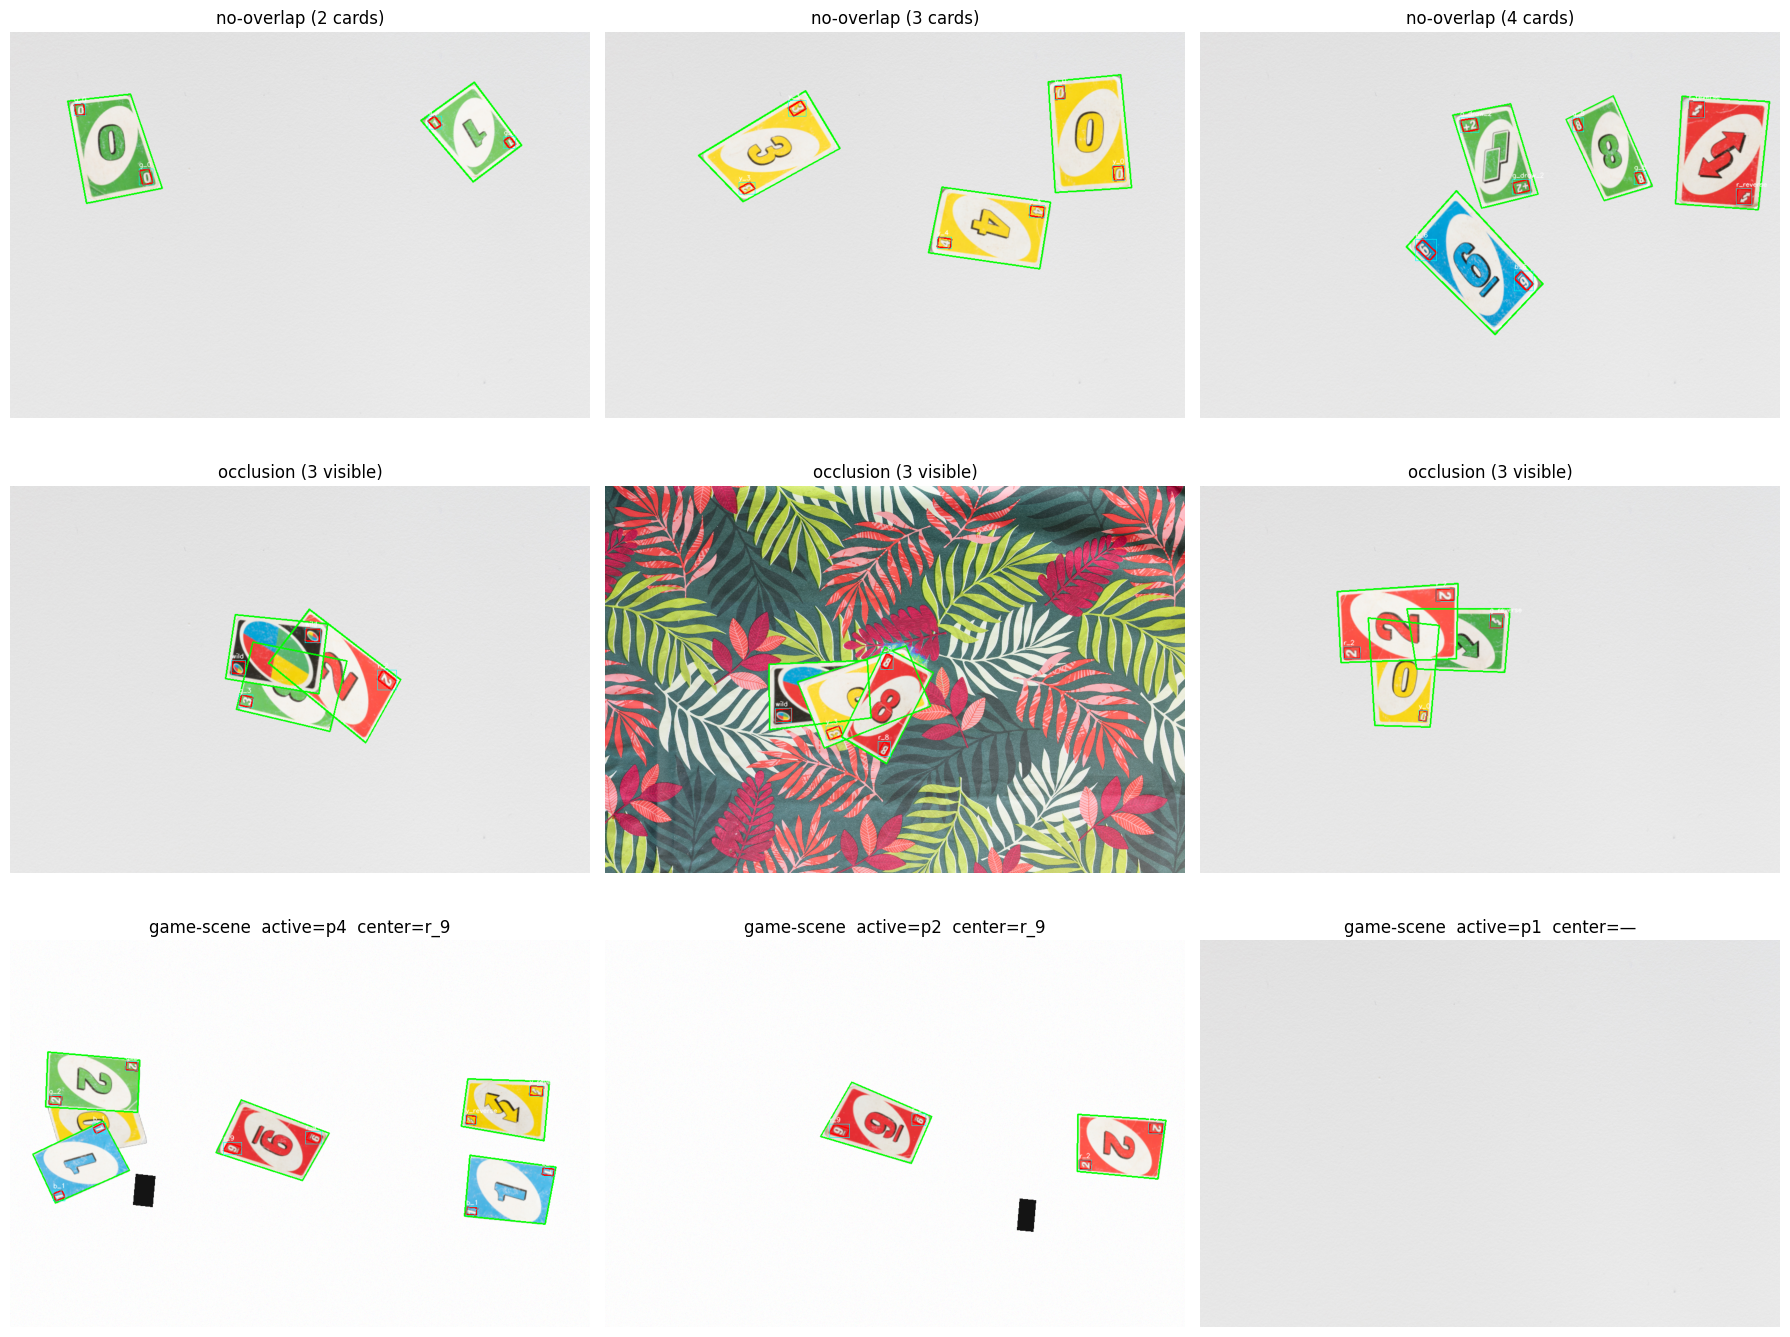

In [15]:
# --- Preview a few samples ------------------------------------------------

def draw_preview(scene_bgr, placed):
    out = scene_bgr.copy()
    for p in placed:
        cv2.polylines(out, [p['quad'].astype(np.int32)], True, (0, 255, 0), 2)
        for lbl, pts in p['hulls']:
            cv2.polylines(out, [pts.astype(np.int32)], True, (0, 0, 255), 2)
            x0, y0 = pts[:, 0].min(), pts[:, 1].min()
            x1, y1 = pts[:, 0].max(), pts[:, 1].max()
            cv2.rectangle(out, (int(x0), int(y0)), (int(x1), int(y1)), (255, 255, 0), 1)
            cv2.putText(out, p['card']['name'], (int(x0), int(y0) - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
    return out


fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i, ax in enumerate(axes.flat):
    if i < 3:
        scene, placed = compose_no_overlap(random.randint(2, 5))
        ax.set_title(f'no-overlap ({len(placed)} cards)')
    elif i < 6:
        scene, placed = compose_occlusion(3)
        ax.set_title(f'occlusion ({len(placed)} visible)')
    else:
        scene, placed, hands, center, active = compose_game_scene()
        ax.set_title(f'game-scene  active={active}  center={center or "—"}')
    ax.imshow(cv2.cvtColor(draw_preview(scene, placed), cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# --- Run full generation --------------------------------------------------
# Tune the counts below; the three composers complement each other.
generate_dataset(n_no_overlap=300, n_occlusion=300, n_game_scene=600)

no-overlap:   0%|          | 0/300 [00:00<?, ?it/s]